In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Superstore.csv", encoding="latin-1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (9994, 21)

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0

Data types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City         

In [ ]:
df_clean = df.copy()

# Make column names easier to use in Python
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Convert date columns
df_clean["order_date"] = pd.to_datetime(df_clean["order_date"])
df_clean["ship_date"] = pd.to_datetime(df_clean["ship_date"])

# Create useful analysis columns
df_clean["order_year"] = df_clean["order_date"].dt.year
df_clean["order_month"] = df_clean["order_date"].dt.month
df_clean["order_month_name"] = df_clean["order_date"].dt.month_name()
df_clean["order_year_month"] = df_clean["order_date"].dt.to_period("M").astype(str)

df_clean["shipping_days"] = (
    df_clean["ship_date"] - df_clean["order_date"]
).dt.days

df_clean["profit_margin"] = np.where(
    df_clean["sales"] != 0,
    df_clean["profit"] / df_clean["sales"],
    np.nan
)

df_clean["discount_band"] = pd.cut(
    df_clean["discount"],
    bins=[-0.01, 0, 0.10, 0.20, 0.40, 1.00],
    labels=["No discount", "1-10%", "11-20%", "21-40%", "41%+"]
)

df_clean["is_loss_making"] = df_clean["profit"] < 0

df_clean.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,discount,profit,order_year,order_month,order_month_name,order_year_month,shipping_days,profit_margin,discount_band,is_loss_making
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,41.9136,2016,11,November,2016-11,3,0.1600,No discount,False
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,219.5820,2016,11,November,2016-11,3,0.3000,No discount,False
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.00,6.8714,2016,6,June,2016-06,4,0.4700,No discount,False
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.45,-383.0310,2015,10,October,2015-10,7,-0.4000,41%+,True
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.20,2.5164,2015,10,October,2015-10,7,0.1125,11-20%,False


In [ ]:
total_sales = df_clean["sales"].sum()
total_profit = df_clean["profit"].sum()
profit_margin = (total_profit / total_sales) * 100
total_orders = df_clean["order_id"].nunique()
loss_making_lines = df_clean["is_loss_making"].sum()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Profit Margin: {profit_margin:.2f}%")
print(f"Total Orders: {total_orders:,}")
print(f"Loss-Making Order Lines: {loss_making_lines:,}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Profit Margin: 12.47%
Total Orders: 5,009
Loss-Making Order Lines: 1,871


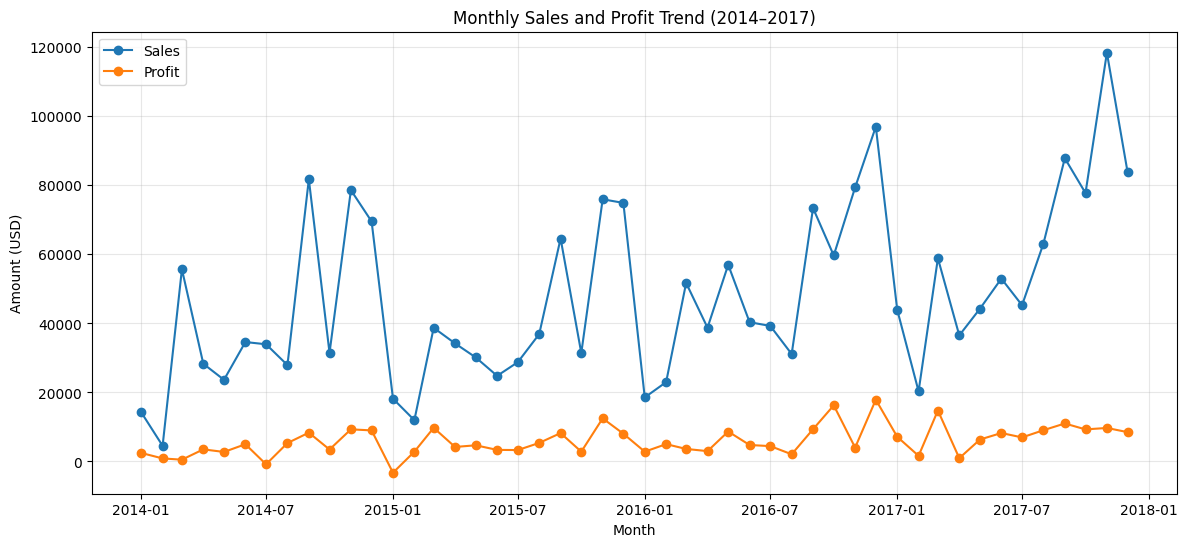

In [ ]:
monthly_performance = (
    df_clean
    .groupby("order_year_month")[["sales", "profit"]]
    .sum()
    .reset_index()
)

monthly_performance["order_year_month"] = pd.to_datetime(
    monthly_performance["order_year_month"]
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_performance["order_year_month"],
    monthly_performance["sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    monthly_performance["order_year_month"],
    monthly_performance["profit"],
    marker="o",
    label="Profit"
)

plt.title("Monthly Sales and Profit Trend (2014–2017)")
plt.xlabel("Month")
plt.ylabel("Amount (USD)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Sales generally increased over the four year period , reaching their highest point neear the end of 2017. Profit was much lokwer than sales throughout the period with a peak near the end of 2016 and a low point in early 2015. This suggests that high sales do not always results in equally high profit.

,category,sales,profit
0,Furniture,741999.7953,18451.2728
1,Office Supplies,719047.0320,122490.8008
2,Technology,836154.0330,145454.9481


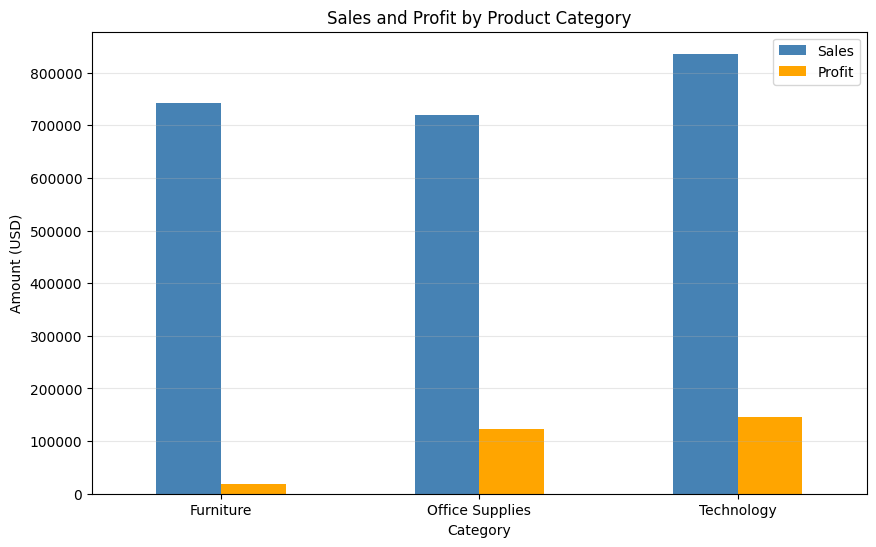

In [ ]:
category_performance = (
    df_clean
    .groupby("category")[["sales", "profit"]]
    .sum()
    .reset_index()
)

display(category_performance)

category_performance.plot(
    x="category",
    y=["sales", "profit"],
    kind="bar",
    figsize=(10, 6),
    color=["steelblue", "orange"]
)

plt.title("Sales and Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Amount (USD)")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.grid(axis="y", alpha=0.3)

plt.show()

,category,sales,profit,profit_margin_percent
2,Technology,836154.0330,145454.9481,17.395712
1,Office Supplies,719047.0320,122490.8008,17.035158
0,Furniture,741999.7953,18451.2728,2.486695


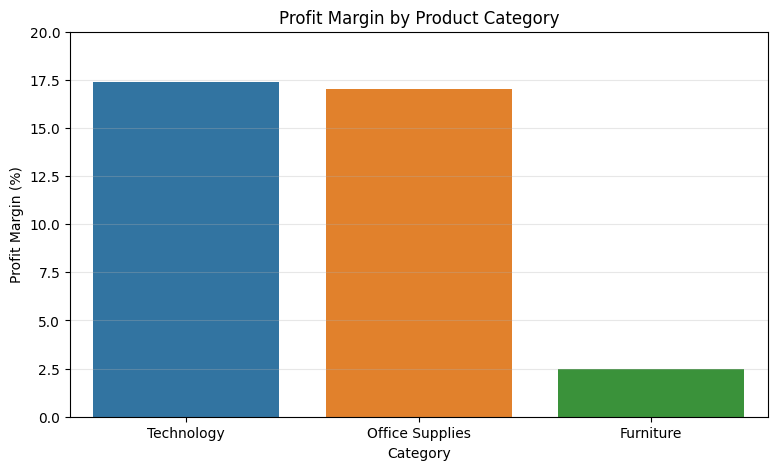

In [ ]:
category_performance["profit_margin_percent"] = (
    category_performance["profit"] / category_performance["sales"]
) * 100

category_performance = category_performance.sort_values(
    "profit_margin_percent",
    ascending=False
)

display(category_performance)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=category_performance,
    x="category",
    y="profit_margin_percent",
    hue="category",
    legend=False
)

plt.title("Profit Margin by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.ylim(0, 20)
plt.grid(axis="y", alpha=0.3)

plt.show()

Furniture generated high sales but had the lowest profit margin . Therefore , the business should reveiw furniture pricing , discounts and low performing sub categories to improve profitability.


,region,sales,profit,profit_margin_percent
3,West,725457.8245,108418.4489,14.944831
1,East,678781.2400,91522.7800,13.483399
2,South,391721.9050,46749.4303,11.934342
0,Central,501239.8908,39706.3625,7.921629


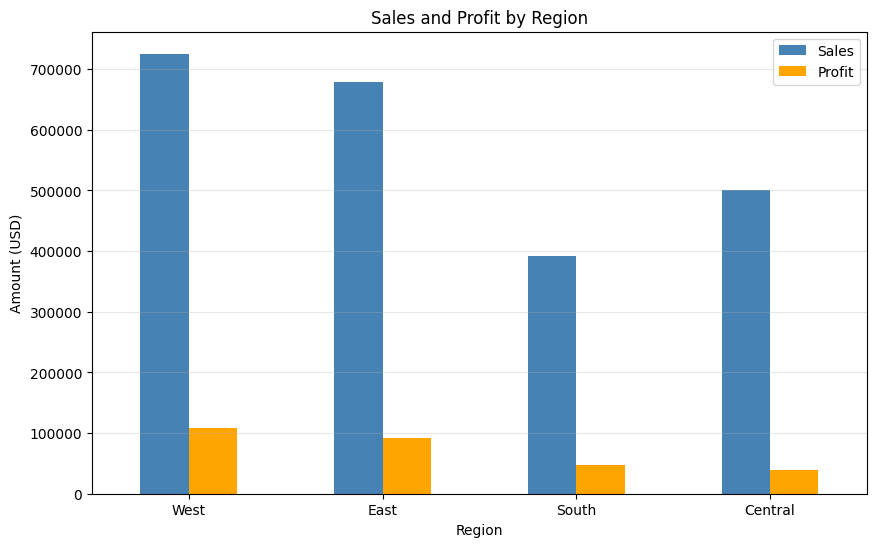

In [ ]:
regional_performance = (
    df_clean
    .groupby("region")[["sales", "profit"]]
    .sum()
    .reset_index()
    .sort_values("profit", ascending=False)
)

regional_performance["profit_margin_percent"] = (
    regional_performance["profit"] / regional_performance["sales"]
) * 100

display(regional_performance)

regional_performance.plot(
    x="region",
    y=["sales", "profit"],
    kind="bar",
    figsize=(10, 6),
    color=["steelblue", "orange"]
)

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount (USD)")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.grid(axis="y", alpha=0.3)

plt.show()

The West region generated the highest profit. Central achieved reasonable sales but comparatively low profit , so its pricing discounting or product mix should be investigated.

Likely reason why central region has high sales with relatively low profit

,discount_band,sales,profit
0,No discount,1.087908e+06,320987.6032
1,1-10%,5.436935e+04,9029.1770
2,11-20%,7.921529e+05,91756.2975
3,21-40%,2.341379e+05,-35817.4655
4,41%+,1.286323e+05,-99558.5905


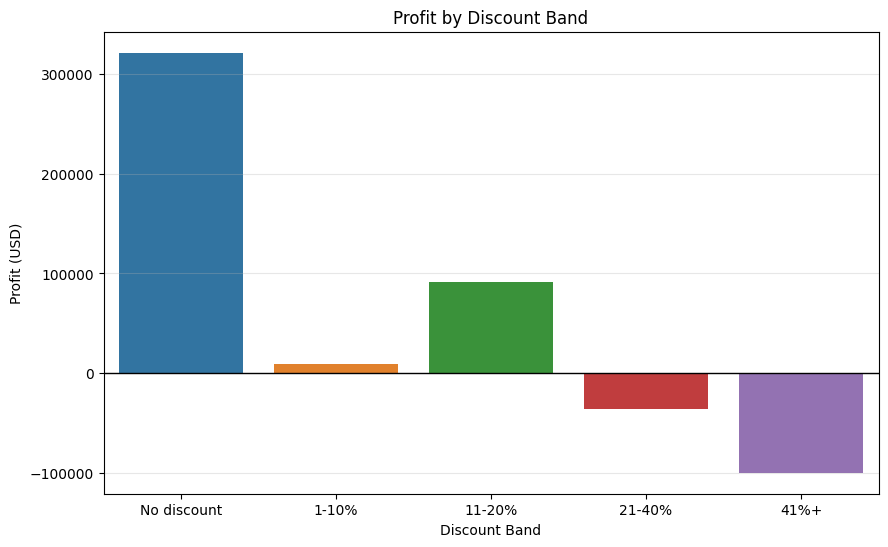

In [ ]:
discount_performance = (
    df_clean
    .groupby("discount_band", observed=False)[["sales", "profit"]]
    .sum()
    .reset_index()
)

discount_order = [
    "No discount",
    "1-10%",
    "11-20%",
    "21-40%",
    "41%+"
]

discount_performance["discount_band"] = pd.Categorical(
    discount_performance["discount_band"],
    categories=discount_order,
    ordered=True
)

discount_performance = discount_performance.sort_values("discount_band")

display(discount_performance)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=discount_performance,
    x="discount_band",
    y="profit",
    hue="discount_band",
    legend=False
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Profit by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit (USD)")
plt.grid(axis="y", alpha=0.3)

plt.show()

Discounts above 20% are unprofitable . The company should reveiw or limit these high discount policies, particularly for products with already low margins.


The sub categories creating losses

,category,sub_category,sales,profit
3,Furniture,Tables,206965.5320,-17725.4811
0,Furniture,Bookcases,114879.9963,-3472.5560
12,Office Supplies,Supplies,46673.5380,-1189.0995
8,Office Supplies,Fasteners,3024.2800,949.5182
15,Technology,Machines,189238.6310,3384.7569
9,Office Supplies,Labels,12486.3120,5546.2540
5,Office Supplies,Art,27118.7920,6527.7870
7,Office Supplies,Envelopes,16476.4020,6964.1767
2,Furniture,Furnishings,91705.1640,13059.1436
4,Office Supplies,Appliances,107532.1610,18138.0054


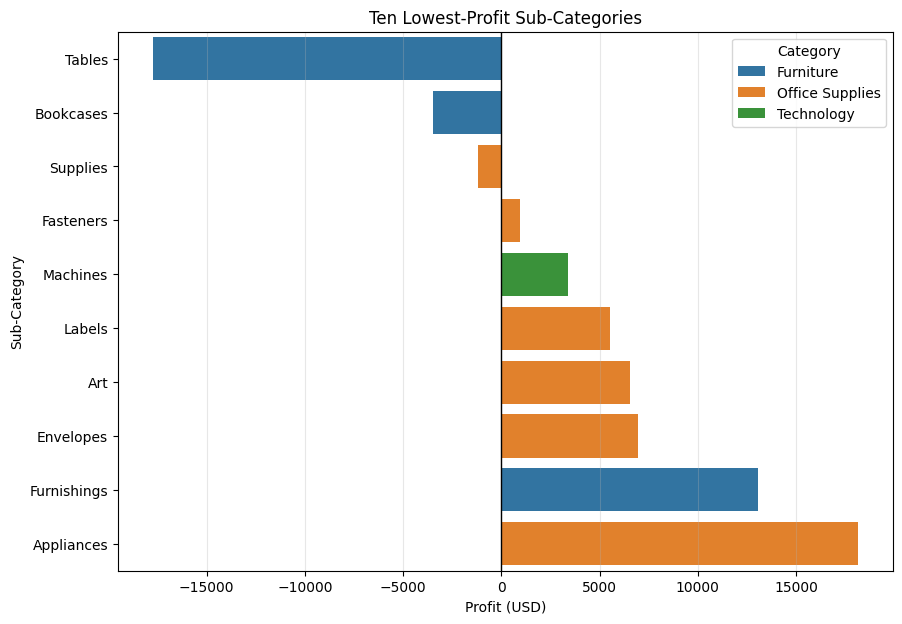

In [ ]:
subcategory_performance = (
    df_clean
    .groupby(["category", "sub_category"])[["sales", "profit"]]
    .sum()
    .reset_index()
    .sort_values("profit")
)

display(subcategory_performance.head(10))

plt.figure(figsize=(10, 7))

sns.barplot(
    data=subcategory_performance.head(10),
    x="profit",
    y="sub_category",
    hue="category",
    dodge=False
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Ten Lowest-Profit Sub-Categories")
plt.xlabel("Profit (USD)")
plt.ylabel("Sub-Category")
plt.legend(title="Category")
plt.grid(axis="x", alpha=0.3)

plt.show()


Tables generated the greatest loss, followed by bookcases and supplies  because tables and bookcases  are furniture sub categories , they help explain why furniture has high sales but weak profitability

Customer segments

,segment,sales,profit,profit_margin_percent
0,Consumer,1.161401e+06,134119.2092,11.548050
1,Corporate,7.061464e+05,91979.1340,13.025506
2,Home Office,4.296531e+05,60298.6785,14.034269


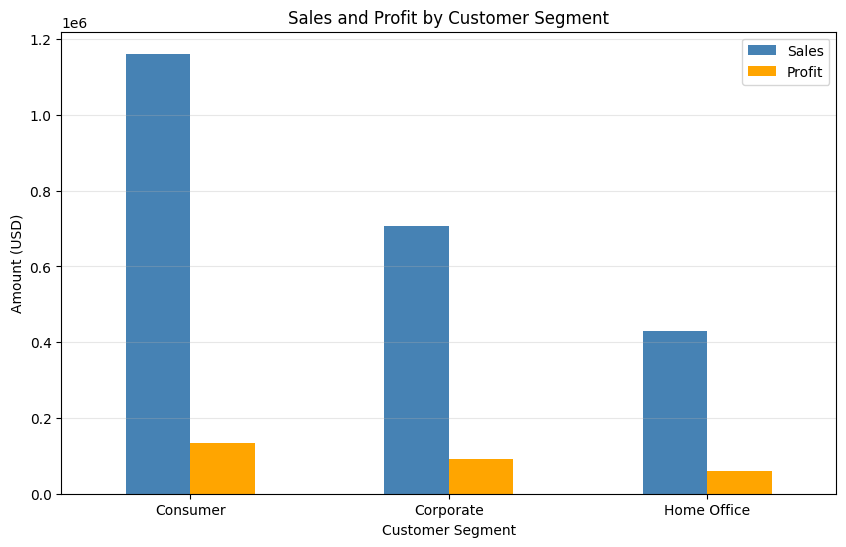

In [ ]:
segment_performance = (
    df_clean
    .groupby("segment")[["sales", "profit"]]
    .sum()
    .reset_index()
    .sort_values("profit", ascending=False)
)

segment_performance["profit_margin_percent"] = (
    segment_performance["profit"] / segment_performance["sales"]
) * 100

display(segment_performance)

segment_performance.plot(
    x="segment",
    y=["sales", "profit"],
    kind="bar",
    figsize=(10, 6),
    color=["steelblue", "orange"]
)

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount (USD)")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.grid(axis="y", alpha=0.3)

plt.show()

category,Furniture,Office Supplies,Technology
segment,,,
Consumer,6991.0786,56330.3210,70797.8096
Corporate,7584.8158,40227.3202,44166.9980
Home Office,3875.3784,25933.1596,30490.1405


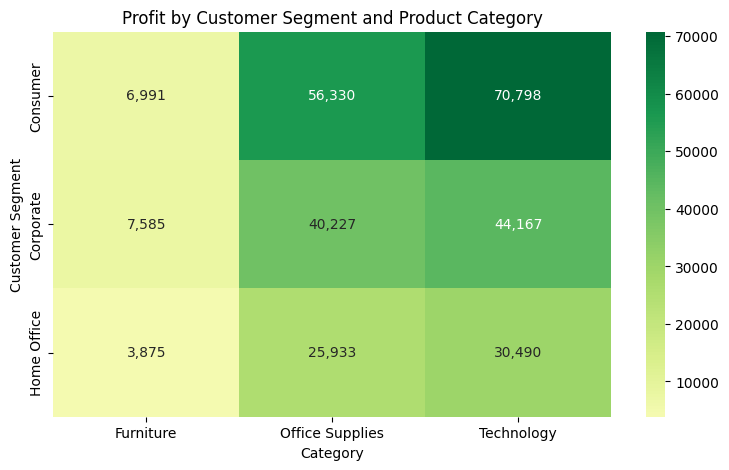

In [ ]:
segment_category_profit = (
    df_clean
    .groupby(["segment", "category"])["profit"]
    .sum()
    .unstack()
)

display(segment_category_profit)

plt.figure(figsize=(9, 5))

sns.heatmap(
    segment_category_profit,
    annot=True,
    fmt=",.0f",
    cmap="RdYlGn",
    center=0
)

plt.title("Profit by Customer Segment and Product Category")
plt.xlabel("Category")
plt.ylabel("Customer Segment")

plt.show()

Home office generated the lowest top\tal profit because it had the smallest sales volume , not because it was efficient. In fact home office achieved the highest profit margin. Furniture 's weak total profitability is driven by liss making sub categories , particularly Tables and bookcases , combined with discounts.

In [ ]:
df_clean.to_csv("retail_sales_clean.csv", index=False)

from google.colab import files
files.download("retail_sales_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# SQL Analysis

In this section, I use SQLite and SQL queries to analyze retail sales performance. The cleaned dataset is loaded into a relational database with fact and dimension tables.

## Database Tables

- **fact_sales:** sales transactions and calculated fields
- **dim_customer:** customer IDs, names, and segments
- **dim_product:** products, categories, and sub-categories
- **dim_location:** country, region, state, city, and postal code

The SQL analysis will examine sales, profit, discounts, products, regions, and customer segments.

In [ ]:
import sqlite3

# Create a SQLite database in Colab
conn = sqlite3.connect("retail_sales.db")

# Create the main sales table
df_clean.to_sql(
    "fact_sales",
    conn,
    if_exists="replace",
    index=False
)

# Create supporting tables
df_clean[
    ["customer_id", "customer_name", "segment"]
].drop_duplicates().to_sql(
    "dim_customer",
    conn,
    if_exists="replace",
    index=False
)

df_clean[
    ["product_id", "product_name", "category", "sub_category"]
].drop_duplicates().to_sql(
    "dim_product",
    conn,
    if_exists="replace",
    index=False
)

df_clean[
    ["country", "region", "state", "city", "postal_code"]
].drop_duplicates().to_sql(
    "dim_location",
    conn,
    if_exists="replace",
    index=False
)

print("SQLite database created successfully.")

SQLite database created successfully.


## SQL Query 1: Executive Performance KPIs

This query calculates the main performance indicators for the business: total sales, total profit, profit margin, number of unique orders, and average order value.

In [ ]:
query_kpis = """
SELECT
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) * 100.0 / SUM(sales), 2) AS profit_margin_percent,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(sales) / COUNT(DISTINCT order_id), 2) AS average_order_value
FROM fact_sales;
"""

kpi_results = pd.read_sql_query(query_kpis, conn)

display(kpi_results)

,total_sales,total_profit,profit_margin_percent,total_orders,average_order_value
0,2297200.86,286397.02,12.47,5009,458.61


## SQL Query 2: Category Profitability Ranking

This query groups sales by product category and uses the SQL `RANK()` window function to rank categories from highest to lowest profit.

In [ ]:
query_category_rank = """
SELECT
    category,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) * 100.0 / SUM(sales), 2) AS profit_margin_percent,
    RANK() OVER (ORDER BY SUM(profit) DESC) AS profit_rank
FROM fact_sales
GROUP BY category
ORDER BY profit_rank;
"""

category_sql_results = pd.read_sql_query(query_category_rank, conn)

display(category_sql_results)

,category,total_sales,total_profit,profit_margin_percent,profit_rank
0,Technology,836154.03,145454.95,17.40,1
1,Office Supplies,719047.03,122490.80,17.04,2
2,Furniture,741999.80,18451.27,2.49,3


## SQL Query 3: Discount Impact Using a CTE

A Common Table Expression (CTE) creates a temporary named result set. This query first summarizes sales and profit by discount band, then calculates the profit margin from that summary.

In [ ]:
query_discount_cte = """
WITH discount_performance AS (
    SELECT
        discount_band,
        COUNT(*) AS order_lines,
        SUM(sales) AS total_sales,
        SUM(profit) AS total_profit
    FROM fact_sales
    GROUP BY discount_band
)
SELECT
    discount_band,
    order_lines,
    ROUND(total_sales, 2) AS total_sales,
    ROUND(total_profit, 2) AS total_profit,
    ROUND(total_profit * 100.0 / total_sales, 2) AS profit_margin_percent
FROM discount_performance
ORDER BY CASE discount_band
    WHEN 'No discount' THEN 1
    WHEN '1-10%' THEN 2
    WHEN '11-20%' THEN 3
    WHEN '21-40%' THEN 4
    WHEN '41%+' THEN 5
END;
"""

discount_sql_results = pd.read_sql_query(query_discount_cte, conn)

display(discount_sql_results)

,discount_band,order_lines,total_sales,total_profit,profit_margin_percent
0,No discount,4798,1087908.47,320987.60,29.51
1,1-10%,94,54369.35,9029.18,16.61
2,11-20%,3709,792152.89,91756.30,11.58
3,21-40%,460,234137.90,-35817.47,-15.30
4,41%+,933,128632.25,-99558.59,-77.40


## SQL Query 4: Customer Segment Performance Using a JOIN

This query joins the sales transaction table with the customer dimension table. It shows how SQL combines related tables through a shared key: `customer_id`.

In [ ]:
query_segment_join = """
SELECT
    c.segment,
    COUNT(DISTINCT f.order_id) AS total_orders,
    ROUND(SUM(f.sales), 2) AS total_sales,
    ROUND(SUM(f.profit), 2) AS total_profit,
    ROUND(SUM(f.profit) * 100.0 / SUM(f.sales), 2) AS profit_margin_percent
FROM fact_sales AS f
JOIN dim_customer AS c
    ON f.customer_id = c.customer_id
GROUP BY c.segment
ORDER BY total_profit DESC;
"""

segment_sql_results = pd.read_sql_query(query_segment_join, conn)

display(segment_sql_results)

,segment,total_orders,total_sales,total_profit,profit_margin_percent
0,Consumer,2586,1161401.34,134119.21,11.55
1,Corporate,1514,706146.37,91979.13,13.03
2,Home Office,909,429653.15,60298.68,14.03


## SQL Query 5: Monthly Sales Growth Using a Window Function

This query uses the `LAG()` window function to access the previous month’s sales. It then calculates the percentage change in sales from one month to the next.

In [ ]:
query_monthly_growth = """
WITH monthly_sales AS (
    SELECT
        order_year_month,
        SUM(sales) AS total_sales,
        SUM(profit) AS total_profit
    FROM fact_sales
    GROUP BY order_year_month
)
SELECT
    order_year_month,
    ROUND(total_sales, 2) AS total_sales,
    ROUND(total_profit, 2) AS total_profit,
    ROUND(
        (total_sales - LAG(total_sales) OVER (ORDER BY order_year_month))
        * 100.0
        / LAG(total_sales) OVER (ORDER BY order_year_month),
        2
    ) AS month_over_month_sales_growth_percent
FROM monthly_sales
ORDER BY order_year_month;
"""

monthly_sql_results = pd.read_sql_query(query_monthly_growth, conn)

display(monthly_sql_results.head(12))

,order_year_month,total_sales,total_profit,month_over_month_sales_growth_percent
0,2014-01,14236.90,2450.19,NaN
1,2014-02,4519.89,862.31,-68.25
2,2014-03,55691.01,498.73,1132.13
3,2014-04,28295.35,3488.84,-49.19
4,2014-05,23648.29,2738.71,-16.42
5,2014-06,34595.13,4976.52,46.29
6,2014-07,33946.39,-841.48,-1.88
7,2014-08,27909.47,5318.10,-17.78
8,2014-09,81777.35,8328.10,193.01
9,2014-10,31453.39,3448.26,-61.54


### SQL Finding: Monthly Sales Growth

Monthly sales fluctuate significantly. Large percentage increases can result from comparison with a low-sales prior month, so month-over-month growth should be interpreted alongside the actual sales value. July 2014 is notable because it generated negative profit despite positive sales.### SQL Finding: Monthly Sales Growth



In [ ]:
df_clean.to_csv("retail_sales_clean.csv", index=False)

from google.colab import files
files.download("retail_sales_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>